In [1]:
from src.DynastyClass import Dynasty
from src.GameOfThronesGraphClass import GameOfThronesGraph
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx



with open('data/game-of-thrones-characters-groups.json') as f:
  json_data = json.load(f)

for data in json_data['groups']:
  house = Dynasty(data['name'])
  for character in data['characters']:
    house.append(character)
  print(house)
  print("Our members:")
  for person in house:
    print(person)
  print(f"We have {house.getStrength()} family members!!!")

This is a House of Stark!
Our members:
Arya Stark
Benjen Stark
Bran Stark
Catelyn Stark
Eddard Stark
Ghost
Grey Wind
Jon Snow
Lady
Nymeria
Rickon Stark
Robb Stark
Sansa Stark
Shaggydog
Summer
We have 15 family members!!!
This is a House of Targaryen!
Our members:
Daenerys Targaryen
Drogon
Rhaegal
Viserion
Viserys Targaryen
We have 5 family members!!!
This is a House of Baratheon!
Our members:
Joffrey Baratheon
Myrcella Baratheon
Renly Baratheon
Robert Baratheon
Selyse Baratheon
Shireen Baratheon
Stannis Baratheon
Tommen Baratheon
Gendry
We have 9 family members!!!
This is a House of Lannister!
Our members:
Cersei Lannister
Jaime Lannister
Kevan Lannister
Lancel Lannister
Tyrion Lannister
Tywin Lannister
We have 6 family members!!!
This is a House of Night's Watch!
Our members:
Alliser Thorne
Eddison Tollett
Grenn
Jeor Mormont
Karl Tanner
Maester Aemon
Olly
Othell Yarwyck
Pypar
Qhorin Halfhand
Rast
Samwell Tarly
Yoren
We have 13 family members!!!
This is a House of Dothraki!
Our members

In [2]:
corpusData = json_data["groups"]
GameOfThronesHouses = GameOfThronesGraph(corpusData)

visualisationData={}
legendData=[]
for house in GameOfThronesHouses:
  print(house)
  print(f"Strength: {house.getStrength()}")
  visualisationData[house.name]=house.getStrength()
  legendData.append(house.name)


This is a House of Stark!
Strength: 15
This is a House of Targaryen!
Strength: 5
This is a House of Baratheon!
Strength: 9
This is a House of Lannister!
Strength: 6
This is a House of Night's Watch!
Strength: 13
This is a House of Dothraki!
Strength: 5
This is a House of Greyjoy!
Strength: 4
This is a House of Tyrell!
Strength: 4
This is a House of Wildlings!
Strength: 11
This is a House of Martell!
Strength: 7
This is a House of Frey!
Strength: 3
This is a House of Tully!
Strength: 2
This is a House of White Walkers!
Strength: 5
This is a House of Include!
Strength: 65


In [3]:
visualisationData

{'Stark': 15,
 'Targaryen': 5,
 'Baratheon': 9,
 'Lannister': 6,
 "Night's Watch": 13,
 'Dothraki': 5,
 'Greyjoy': 4,
 'Tyrell': 4,
 'Wildlings': 11,
 'Martell': 7,
 'Frey': 3,
 'Tully': 2,
 'White Walkers': 5,
 'Include': 65}

In [4]:
legendData

['Stark',
 'Targaryen',
 'Baratheon',
 'Lannister',
 "Night's Watch",
 'Dothraki',
 'Greyjoy',
 'Tyrell',
 'Wildlings',
 'Martell',
 'Frey',
 'Tully',
 'White Walkers',
 'Include']

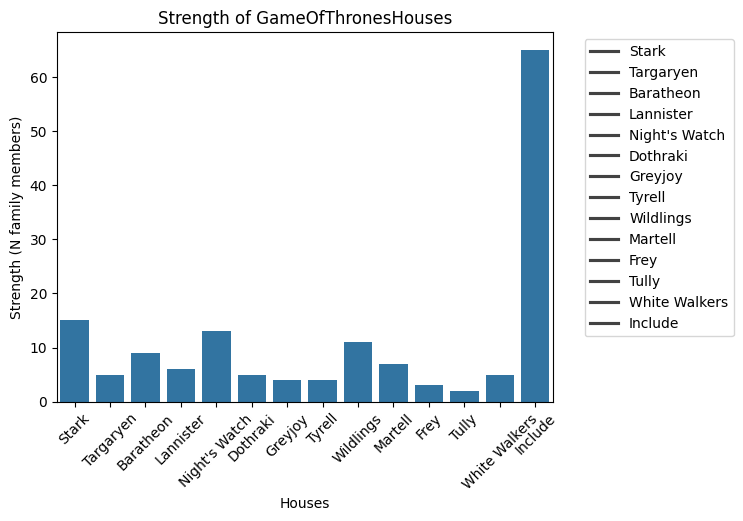

In [5]:

x = list(visualisationData.keys())
y = list(visualisationData.values())

ax = sns.barplot(x=x, y=y)

ax.legend(legendData)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1.05, 1))
ax.set(
  xlabel = "Houses",
    ylabel = 'Strength (N family members)',
    title = 'Strength of GameOfThronesHouses'
)

plt.xticks(rotation=45)
plt.show()

g = nx.Graph()


In [6]:
N_houses = 0
colorKeys = []
for house in GameOfThronesHouses:
  if house.name != "Include":
    N_houses += 1
    colorKeys.append(house.name)
sns.color_palette("husl", N_houses)

list(sns.color_palette("husl", N_houses))

[(0.9677975592919913, 0.44127456009157356, 0.5358103155058701),
 (0.9218528551477547, 0.500345433264, 0.19606247053399534),
 (0.756593795426372, 0.58660455674609, 0.19460548454202936),
 (0.6280838378584804, 0.6317149736053096, 0.19371846323785552),
 (0.44127702936426016, 0.6747986506725627, 0.19278677787286805),
 (0.19925855442314272, 0.6935861010390585, 0.43494846713408325),
 (0.20730980534421067, 0.6820252887361699, 0.5931178995944008),
 (0.213603436221035, 0.6724447149771248, 0.6900417229996091),
 (0.2218708221705632, 0.6590814541823624, 0.7990680761766646),
 (0.38670894369284947, 0.6148978276981065, 0.9585912355668605),
 (0.7049741506310939, 0.5248938690186019, 0.9581527270311664),
 (0.9538763597142671, 0.3594595647605631, 0.95756585161213),
 (0.9637107389395935, 0.4095260281088575, 0.7436447221919831)]

In [7]:
colorKeys

['Stark',
 'Targaryen',
 'Baratheon',
 'Lannister',
 "Night's Watch",
 'Dothraki',
 'Greyjoy',
 'Tyrell',
 'Wildlings',
 'Martell',
 'Frey',
 'Tully',
 'White Walkers']

In [8]:
nodeColors = dict(zip(colorKeys, [tuple(int(c * 255) for c in cs) for cs in sns.color_palette("husl", N_houses)]))
nodeColors

{'Stark': (246, 112, 136),
 'Targaryen': (235, 127, 49),
 'Baratheon': (192, 149, 49),
 'Lannister': (160, 161, 49),
 "Night's Watch": (112, 172, 49),
 'Dothraki': (50, 176, 110),
 'Greyjoy': (52, 173, 151),
 'Tyrell': (54, 171, 175),
 'Wildlings': (56, 168, 203),
 'Martell': (98, 156, 244),
 'Frey': (179, 133, 244),
 'Tully': (243, 91, 244),
 'White Walkers': (245, 104, 189)}

In [9]:
for house in GameOfThronesHouses:
    if house.name != "Include":
        g.add_node(house.name, size=house.getStrength())

for node, attrs in g.nodes(data=True):
    print(f"Node: {node}, Attributes: {attrs}")

Node: Stark, Attributes: {'size': 15}
Node: Targaryen, Attributes: {'size': 5}
Node: Baratheon, Attributes: {'size': 9}
Node: Lannister, Attributes: {'size': 6}
Node: Night's Watch, Attributes: {'size': 13}
Node: Dothraki, Attributes: {'size': 5}
Node: Greyjoy, Attributes: {'size': 4}
Node: Tyrell, Attributes: {'size': 4}
Node: Wildlings, Attributes: {'size': 11}
Node: Martell, Attributes: {'size': 7}
Node: Frey, Attributes: {'size': 3}
Node: Tully, Attributes: {'size': 2}
Node: White Walkers, Attributes: {'size': 5}


In [10]:
for house in GameOfThronesHouses:
    if house.name != "Include":
        for ch in house:
            g.add_node(ch)


for node, attrs in g.nodes(data=True):
    print(f"Node: {node}, Attributes: {attrs}")

Node: Stark, Attributes: {'size': 15}
Node: Targaryen, Attributes: {'size': 5}
Node: Baratheon, Attributes: {'size': 9}
Node: Lannister, Attributes: {'size': 6}
Node: Night's Watch, Attributes: {'size': 13}
Node: Dothraki, Attributes: {'size': 5}
Node: Greyjoy, Attributes: {'size': 4}
Node: Tyrell, Attributes: {'size': 4}
Node: Wildlings, Attributes: {'size': 11}
Node: Martell, Attributes: {'size': 7}
Node: Frey, Attributes: {'size': 3}
Node: Tully, Attributes: {'size': 2}
Node: White Walkers, Attributes: {'size': 5}
Node: Arya Stark, Attributes: {}
Node: Benjen Stark, Attributes: {}
Node: Bran Stark, Attributes: {}
Node: Catelyn Stark, Attributes: {}
Node: Eddard Stark, Attributes: {}
Node: Ghost, Attributes: {}
Node: Grey Wind, Attributes: {}
Node: Jon Snow, Attributes: {}
Node: Lady, Attributes: {}
Node: Nymeria, Attributes: {}
Node: Rickon Stark, Attributes: {}
Node: Robb Stark, Attributes: {}
Node: Sansa Stark, Attributes: {}
Node: Shaggydog, Attributes: {}
Node: Summer, Attribute

In [11]:
myEdges = []

for house in GameOfThronesHouses:
    if house.name != "Include":
        for ch in house:
            myEdges.append((ch, house.name))
            for ch2 in house:
                if ch2 != ch:
                    myEdges.append((ch2, ch))

myEdges

[('Arya Stark', 'Stark'),
 ('Benjen Stark', 'Arya Stark'),
 ('Bran Stark', 'Arya Stark'),
 ('Catelyn Stark', 'Arya Stark'),
 ('Eddard Stark', 'Arya Stark'),
 ('Ghost', 'Arya Stark'),
 ('Grey Wind', 'Arya Stark'),
 ('Jon Snow', 'Arya Stark'),
 ('Lady', 'Arya Stark'),
 ('Nymeria', 'Arya Stark'),
 ('Rickon Stark', 'Arya Stark'),
 ('Robb Stark', 'Arya Stark'),
 ('Sansa Stark', 'Arya Stark'),
 ('Shaggydog', 'Arya Stark'),
 ('Summer', 'Arya Stark'),
 ('Benjen Stark', 'Stark'),
 ('Arya Stark', 'Benjen Stark'),
 ('Bran Stark', 'Benjen Stark'),
 ('Catelyn Stark', 'Benjen Stark'),
 ('Eddard Stark', 'Benjen Stark'),
 ('Ghost', 'Benjen Stark'),
 ('Grey Wind', 'Benjen Stark'),
 ('Jon Snow', 'Benjen Stark'),
 ('Lady', 'Benjen Stark'),
 ('Nymeria', 'Benjen Stark'),
 ('Rickon Stark', 'Benjen Stark'),
 ('Robb Stark', 'Benjen Stark'),
 ('Sansa Stark', 'Benjen Stark'),
 ('Shaggydog', 'Benjen Stark'),
 ('Summer', 'Benjen Stark'),
 ('Bran Stark', 'Stark'),
 ('Arya Stark', 'Bran Stark'),
 ('Benjen Stark', '

In [12]:
g.add_edges_from(myEdges)

list(g.edges)

[('Stark', 'Arya Stark'),
 ('Stark', 'Benjen Stark'),
 ('Stark', 'Bran Stark'),
 ('Stark', 'Catelyn Stark'),
 ('Stark', 'Eddard Stark'),
 ('Stark', 'Ghost'),
 ('Stark', 'Grey Wind'),
 ('Stark', 'Jon Snow'),
 ('Stark', 'Lady'),
 ('Stark', 'Nymeria'),
 ('Stark', 'Rickon Stark'),
 ('Stark', 'Robb Stark'),
 ('Stark', 'Sansa Stark'),
 ('Stark', 'Shaggydog'),
 ('Stark', 'Summer'),
 ('Targaryen', 'Daenerys Targaryen'),
 ('Targaryen', 'Drogon'),
 ('Targaryen', 'Rhaegal'),
 ('Targaryen', 'Viserion'),
 ('Targaryen', 'Viserys Targaryen'),
 ('Baratheon', 'Joffrey Baratheon'),
 ('Baratheon', 'Myrcella Baratheon'),
 ('Baratheon', 'Renly Baratheon'),
 ('Baratheon', 'Robert Baratheon'),
 ('Baratheon', 'Selyse Baratheon'),
 ('Baratheon', 'Shireen Baratheon'),
 ('Baratheon', 'Stannis Baratheon'),
 ('Baratheon', 'Tommen Baratheon'),
 ('Baratheon', 'Gendry'),
 ('Lannister', 'Cersei Lannister'),
 ('Lannister', 'Jaime Lannister'),
 ('Lannister', 'Kevan Lannister'),
 ('Lannister', 'Lancel Lannister'),
 ('Lan

In [13]:
len(list(g.edges))

445

In [14]:
from pyvis.network import Network

GameOfThronesNet = Network(
    bgcolor ="#242020",
    font_color = "white",
    height = "1000px",
    width = "100%",
    notebook=True,
    cdn_resources = "remote"
)

GameOfThronesNet.from_nx(g)

In [15]:
for node in GameOfThronesNet.nodes:
    if node["id"] in GameOfThronesHouses:
        node["color"] = '#%02x%02x%02x' % nodeColors[node["id"]]
    else:
        for house in GameOfThronesHouses:
            if house.name != "Include":
                if node["id"] in house:
                    node["color"] = '#%02x%02x%02x' % nodeColors[house.name]

In [16]:
GameOfThronesNet.nodes

[{'color': '#f67088',
  'size': 15,
  'id': 'Stark',
  'label': 'Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Arya Stark',
  'label': 'Arya Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Benjen Stark',
  'label': 'Benjen Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Bran Stark',
  'label': 'Bran Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Catelyn Stark',
  'label': 'Catelyn Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Eddard Stark',
  'label': 'Eddard Stark',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Ghost',
  'label': 'Ghost',
  'shape': 'dot',
  'font': {'color': 'white'}},
 {'color': '#f67088',
  'size': 10,
  'id': 'Grey Wind',
  'label': 'Grey Wind',
 

In [17]:
GameOfThronesNet.show("game_of_thronesNet.html", notebook=False)

game_of_thronesNet.html
